In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score



In [5]:
#get the boston dataframe directly
from sklearn.datasets import fetch_openml
df = fetch_openml(name ="boston",version = 1 ,as_frame= True)

In [6]:
dataset = df.data
dataset

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296.0,15.3,396.90,4.98
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242.0,17.8,396.90,9.14
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242.0,17.8,392.83,4.03
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222.0,18.7,394.63,2.94
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222.0,18.7,396.90,5.33
...,...,...,...,...,...,...,...,...,...,...,...,...,...
501,0.06263,0.0,11.93,0,0.573,6.593,69.1,2.4786,1,273.0,21.0,391.99,9.67
502,0.04527,0.0,11.93,0,0.573,6.120,76.7,2.2875,1,273.0,21.0,396.90,9.08
503,0.06076,0.0,11.93,0,0.573,6.976,91.0,2.1675,1,273.0,21.0,396.90,5.64
504,0.10959,0.0,11.93,0,0.573,6.794,89.3,2.3889,1,273.0,21.0,393.45,6.48


In [7]:
# independent and dependent features 
x = dataset
y = df.target

In [8]:
#train test split
X_train,X_test,y_train,y_test = train_test_split(x,y,test_size= 0.3,random_state= 45)

In [9]:
#standarise the data in training and testing x
scaler = StandardScaler()
X_train = scaler.fit_transform(
    X_train,
)
X_test = scaler.transform(X_test)

In [10]:

#cross validation 
regression = LinearRegression()
regression.fit(X_train,y_train)

LinearRegression()

In [11]:
mse = cross_val_score(regression,X_train,y_train,scoring="neg_mean_squared_error",cv = 5)

In [12]:
np.mean(mse)

-24.166811763160432

In [13]:
#prediction 
reg_pred =regression.predict(X_test)

In [14]:
reg_pred

array([10.00376482, 23.43523897, 24.97427528, 21.49513418, 35.087565  ,
       14.4073179 , 19.53619664, 19.05985671, 27.75456432, 17.46204576,
       14.58406759, 20.1053761 , 36.24481005, 23.76497262, 16.33666771,
       20.04301995, 28.23656578, 11.3120847 , 15.83752045, 22.40804802,
       22.43870432, 14.02359736, 19.9263803 , 32.30256753, 22.55245086,
       27.59507183, 23.04764447,  7.5166162 , 26.13123837, 19.31598931,
       21.3574126 ,  8.47827666, 28.07099631, 24.93339977, 35.83055122,
       25.51079562, 39.48633873,  2.31693321, 31.49374242, 32.59170008,
       19.53631358, 21.99811248, 17.22889357, 31.08987315, 18.82675489,
       18.4344953 , 28.68498327, 28.22378217, 18.42883189, 22.09920102,
       42.71604042, 16.17923339, 27.80491805, 35.20872021, 16.35959907,
       31.2972707 ,  6.02955375, 13.53746555, 18.76542575, 19.79916844,
       14.26765114, 18.28220829, 36.95961088, 35.63832362, 17.984269  ,
       12.91788898, 38.7813029 , 36.25991168, 14.47124049, 19.57

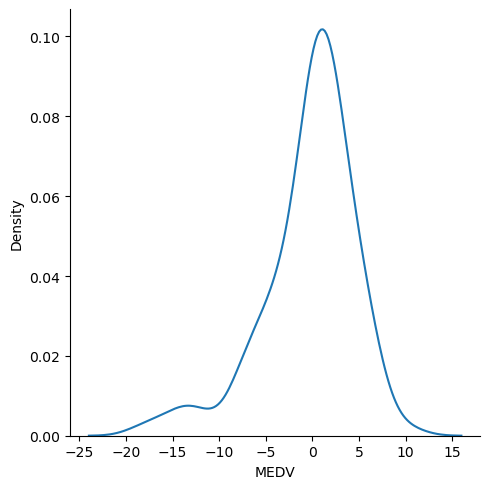

In [15]:
#comapre the predicted value and y_test to get the distance problems in our model
import seaborn as sns
sns.displot(reg_pred - y_test,kind= 'kde')


In [16]:
# get the r^2 error
from sklearn.metrics import r2_score
score = r2_score(reg_pred,y_test)
print(f"This is the outcome using Linear Regression : {score}")

This is the outcome using Linear Regression : 0.6249713338507568


    Using Ridge Regression

In [17]:
from sklearn.linear_model import Ridge
from sklearn.model_selection import GridSearchCV

In [18]:
ridge = Ridge()

In [19]:
ridge

Ridge()

In [21]:
parameter ={"alpha" : [1,2,5,10,20,30,40,50,60,70,80,90]}

ridgecv = GridSearchCV(ridge,param_grid=parameter,scoring = "neg_mean_squared_error",cv = 5 )
ridgecv.fit(X_train,y_train)

GridSearchCV(cv=5, estimator=Ridge(),
             param_grid={'alpha': [1, 2, 5, 10, 20, 30, 40, 50, 60, 70, 80,
                                   90]},
             scoring='neg_mean_squared_error')

In [ ]:
print(ridgecv.best_params_) #get the best aplha to use for next step

{'alpha': 10}


In [23]:
print(ridgecv.best_score_)

-23.97433763163914


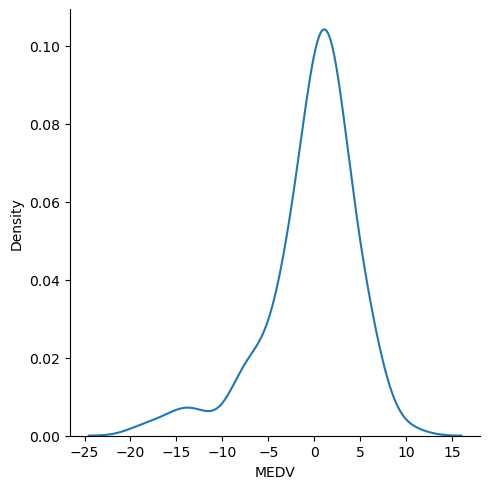

In [24]:
ridge_pred = ridgecv.predict(X_test)
sns.displot(ridge_pred - y_test,kind= 'kde')

In [26]:
score = r2_score(ridge_pred,y_test)
score

0.602331740414416

    Lasso Regression

In [27]:
from sklearn.linear_model import Lasso

In [28]:
lasso =Lasso()

In [29]:
parameter ={"alpha" : [1,2,5,10,20,30,40,50,60,70,80,90]}

lassocv = GridSearchCV(lasso,param_grid=parameter,scoring = "neg_mean_squared_error",cv = 5 )
lassocv.fit(X_train,y_train)

GridSearchCV(cv=5, estimator=Lasso(),
             param_grid={'alpha': [1, 2, 5, 10, 20, 30, 40, 50, 60, 70, 80,
                                   90]},
             scoring='neg_mean_squared_error')

In [34]:
print(ridgecv.best_params_) #get the best aplha to use for next step
print(lassocv.best_score_)

{'alpha': 10}
-29.2073179468256


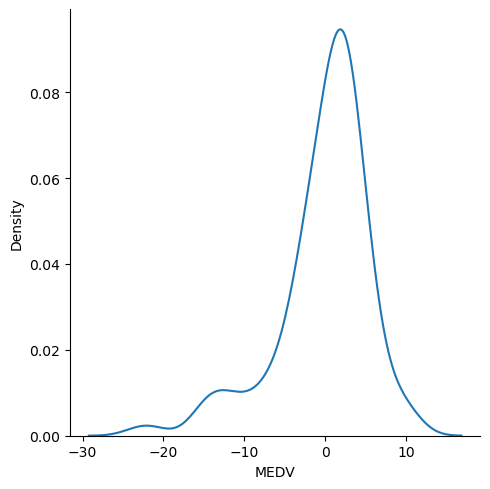

In [30]:
lasso_pred = lassocv.predict(X_test)
sns.displot(lasso_pred - y_test,kind= 'kde')

In [31]:
score = r2_score(lasso_pred,y_test)
score

0.191230739072771